# 02 - Recursive Chunking

## Objective

Create chunks using RecursiveCharacterTextSplitter.

Pipeline 1:

- Recursive Chunking
- MiniLM Embeddings
- ChromaDB
- Qwen3:14B

## Purpose

Create a baseline chunking strategy for comparison.

In [3]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print(f"Project Root: {project_root}")

Project Root: d:\AI\Projects\oracle-rag-comparison-lab


In [5]:
from src.config import DOCS_PATH
from src.loaders.document_loader import DocumentLoader

print(f"Documents Path: {DOCS_PATH}")

Documents Path: ../docs


In [6]:
loader = DocumentLoader(DOCS_PATH)

documents = loader.load()

print(f"Source Documents: {len(documents):,}")

Starting Document Loading...

Loading PDF : iSupplier_portal.pdf

Loading PDF : Purchasing_manual.pdf


DOCUMENT LOADING SUMMARY
PDF Files Loaded   : 2
DOCX Files Loaded  : 0
XLSX Files Loaded  : 0
Total Documents    : 1502
Source Documents: 1,502


In [8]:
from langchain_text_splitters import (
    RecursiveCharacterTextSplitter
)

In [9]:
recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

recursive_chunks = recursive_splitter.split_documents(
    documents
)

print(
    f"Total Chunks Created: {len(recursive_chunks):,}"
)

Total Chunks Created: 3,519


In [10]:
chunk_lengths = [
    len(chunk.page_content)
    for chunk in recursive_chunks
]

print("=" * 80)

print("RECURSIVE CHUNKING STATISTICS")

print("=" * 80)

print(f"Chunk Count     : {len(chunk_lengths):,}")

print(f"Min Length      : {min(chunk_lengths):,}")

print(f"Max Length      : {max(chunk_lengths):,}")

print(
    f"Average Length  : {sum(chunk_lengths)/len(chunk_lengths):.0f}"
)

RECURSIVE CHUNKING STATISTICS
Chunk Count     : 3,519
Min Length      : 1
Max Length      : 1,000
Average Length  : 802


In [12]:
for i, chunk in enumerate(recursive_chunks[:3]):

    print("\n" + "=" * 80)

    print(f"CHUNK #{i+1}")

    print("=" * 80)

    print(chunk.page_content[:1000])


CHUNK #1
Oracle® iSupplier Portal
 User's Guide 
Release 12.2
 Part No. E48972-13
October 2025

CHUNK #2
Oracle iSupplier Portal User's Guide , Release 12.2
Part No. E48972-13
Copyright © 2009, 2025, Oracle and/or its affiliates. 
Primary Author:     Chetna Arora
Contributing Author:     Gowri Arur, Pragya Nair, Smile Nagpal
This software and related documentation are provided under a license agreement containing restrictions on 
use and disclosure and are protected by intellectual property laws. Except as expressly permitted in your 
license agreement or allowed by law, you may not use, copy, reproduce, translate, broadcast, modify, license, 
transmit, distribute, exhibit, perform, publish, or display any part, in any form, or by any means. Reverse 
engineering, disassembly, or decompilation of this software, unless required by law for interoperability, is 
prohibited. 
The information contained herein is subject to change without notice and is not warranted to be error-free. If 
you

In [13]:
recursive_chunks[0].metadata

{'source': 'iSupplier_portal.pdf', 'file_type': 'pdf', 'page': 1}

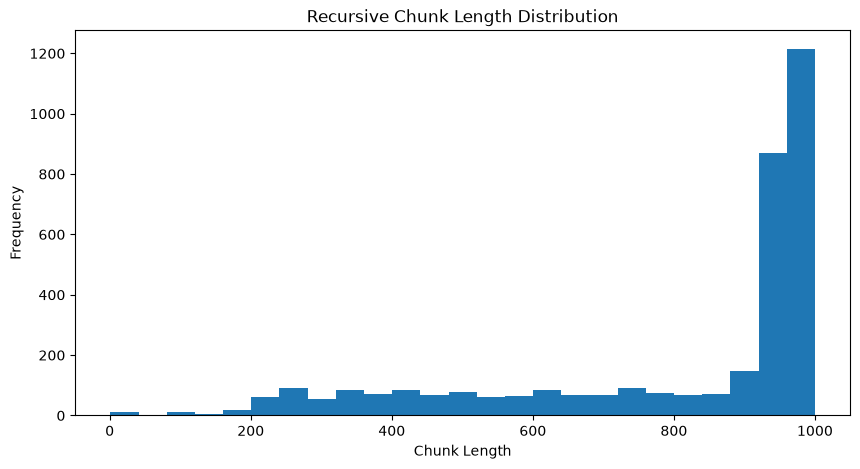

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    chunk_lengths,
    bins=25
)

plt.title(
    "Recursive Chunk Length Distribution"
)

plt.xlabel("Chunk Length")

plt.ylabel("Frequency")

plt.show()

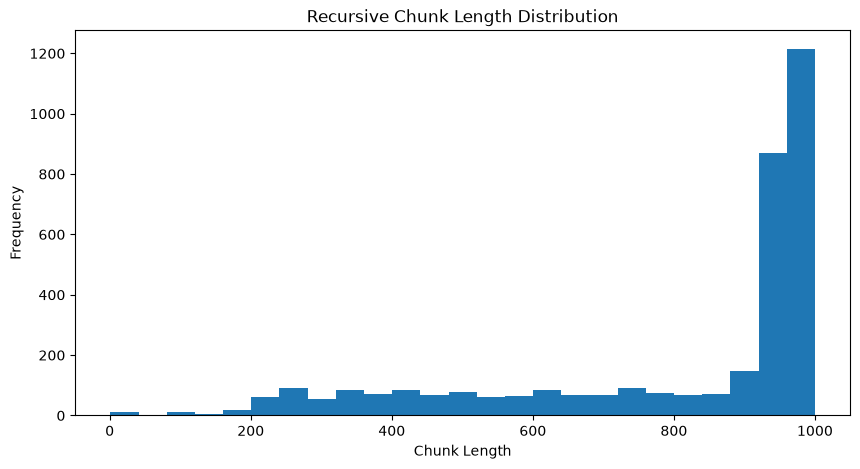

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(
    chunk_lengths,
    bins=25
)

plt.title(
    "Recursive Chunk Length Distribution"
)

plt.xlabel("Chunk Length")

plt.ylabel("Frequency")

plt.savefig(
    "../screenshots/chunking/recursive_chunk_length_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()

In [16]:
small_chunks = [
    chunk
    for chunk in recursive_chunks
    if len(chunk.page_content.strip()) < 20
]

print(
    f"Small Chunks Found: {len(small_chunks)}"
)

Small Chunks Found: 3


In [17]:
for i, chunk in enumerate(small_chunks[:10]):

    print("\n" + "=" * 80)

    print(f"SMALL CHUNK #{i+1}")

    print("=" * 80)

    print(
        f"Length: {len(chunk.page_content)}"
    )

    print(
        repr(chunk.page_content)
    )

    print(
        chunk.metadata
    )


SMALL CHUNK #1
Length: 1
'x'
{'source': 'Purchasing_manual.pdf', 'file_type': 'pdf', 'page': 10}

SMALL CHUNK #2
Length: 3
'xii'
{'source': 'Purchasing_manual.pdf', 'file_type': 'pdf', 'page': 12}

SMALL CHUNK #3
Length: 3
'xvi'
{'source': 'Purchasing_manual.pdf', 'file_type': 'pdf', 'page': 16}
